# EP 1 – Cálculos Complexos com Séries de Taylor

**Tema:** função $f(x) = x \cdot e^x$ (exponencial × x)

**Integrantes:** Pedro Henrique Patricio de Souza, Cauã Caravalho de Oliveira, João Pedro Barbosa Moz

**Disciplina:** Cálculo II

Este notebook apresenta a análise matemática e os resultados computacionais da aproximação de Maclaurin (série de Taylor centrada em $a = 0$) de $f(x) = x \cdot e^x$. Para explorar os valores com sliders, rode o simulador interativo (`python3 src/simulador.py`, ver o `README.md` da raiz).

## 1. Derivadas manuais e expressão geral

As derivadas são calculadas à mão pela regra do produto:

$$\frac{d}{dx}[u(x) \cdot v(x)] = u'(x)v(x) + u(x)v'(x)$$

Com $u(x) = x \implies u'(x) = 1$ e $v(x) = e^x \implies v'(x) = e^x$:

- Ordem $0$: $f^{(0)}(x) = x e^x \implies f^{(0)}(0) = 0 \cdot e^0 = 0$
- Ordem $1$: $f^{(1)}(x) = 1 \cdot e^x + x \cdot e^x = (x + 1)e^x \implies f^{(1)}(0) = 1$
- Ordem $2$: $f^{(2)}(x) = e^x + (x + 1)e^x = (x + 2)e^x \implies f^{(2)}(0) = 2$
- Ordem $3$: $f^{(3)}(x) = e^x + (x + 2)e^x = (x + 3)e^x \implies f^{(3)}(0) = 3$
- Ordem $n$ (geral, por indução): $f^{(n)}(x) = (x + n)e^x \implies f^{(n)}(0) = n$

_Indução:_ se $f^{(n)}(x) = (x+n)e^x$, então $f^{(n+1)}(x) = e^x + (x+n)e^x = (x+n+1)e^x$.

## 2. Série de Maclaurin

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(0)}{n!} x^n$$

Substituindo $f^{(n)}(0) = n$ (o termo $n=0$ vale zero):

$$f(x) = \sum_{n=1}^{\infty} \frac{n}{n!} x^n = \sum_{n=1}^{\infty} \frac{x^n}{(n-1)!} = x \sum_{k=0}^{\infty} \frac{x^k}{k!}$$

Expandindo até o termo $N$:

$$f(x) \approx x + x^2 + \frac{x^3}{2!} + \frac{x^4}{3!} + \dots + \frac{x^N}{(N-1)!}$$

O raio de convergência é infinito (teste da razão: $|x|/n \to 0$).

## 3. Definição do limite $N$

A escolha de $N$ combina dois critérios.

**3.1 Precisão de ponto flutuante (IEEE 754, `float64`).** A precisão relativa da máquina é $\epsilon_{mach} \approx 2.22 \times 10^{-16}$. Quando o termo da série fica menor que isso em relação ao valor acumulado,

$$\frac{|x|^N}{(N-1)!} < \epsilon_{mach} \cdot |f(x)|$$

somar mais termos não altera mais o resultado. É por isso que o erro dos gráficos para de cair perto de $10^{-16}$.

**3.2 Garantia matemática (resto de Lagrange).** Para $|x| \le a$:

$$|R_N(x)| \le \frac{(N+1+a)\, e^{a}\, a^{N+1}}{(N+1)!}$$

Escolhemos o menor $N$ cuja cota fica abaixo de uma tolerância (aqui $10^{-12}$). O $N$ depende do intervalo em que se quer usar a fórmula (tabela abaixo).

**3.3 Critério de parada dinâmico.** Em vez de fixar $N$, para-se quando o novo termo $|t_N|$ fica menor que uma tolerância (ex.: $10^{-15}$).

In [1]:
import math
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

# o notebook fica em src/, junto do taylor.py
sys.path.insert(0, os.getcwd())
import taylor as ty

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})

def exato(x):
    return x * math.exp(x)

def erro_rel(v, x):
    e = exato(x)
    return abs(v - e) / abs(e) if e != 0 else abs(v)

In [2]:
# Menor N com cota de Lagrange < 1e-12, por intervalo [-a, a]
print(f"{'a':>5} | {'N mínimo':>8} | {'cota com esse N':>16}")
for a in (0.5, 1, 2, 5):
    N = ty.escolher_N(a, 1e-12)
    print(f"{a:>5} | {N:>8} | {ty.cota_lagrange(N, a):>16.2e}")

    a | N mínimo |  cota com esse N
  0.5 |       12 |         4.36e-13
    1 |       16 |         1.38e-13
    2 |       21 |         6.62e-13
    5 |       35 |         2.38e-13


## 4. Código otimizado

Para evitar o custo e o overflow de calcular fatoriais e potências a cada termo, usa-se a recorrência:

$$t_1 = x, \qquad t_n = t_{n-1} \cdot \frac{x}{n-1} \quad (n \ge 2)$$

Abaixo, a função do grupo (vetorizada com NumPy) e uma versão com critério de parada dinâmico.

In [3]:
def taylor_x_exp_x(x, n_terms):
    '''
    Aproximação por série de Taylor de f(x) = x * e^x centrada em a = 0.

    Parâmetros:
        x (float ou np.ndarray): valor ou vetor de entrada.
        n_terms (int): número de termos (N) da série.

    Retorna:
        float ou np.ndarray: valor aproximado de f(x).
    '''
    x = np.asarray(x, dtype=np.float64)
    total = np.copy(x)
    termo_atual = np.copy(x)

    for n in range(2, n_terms + 1):
        termo_atual = termo_atual * x / (n - 1)
        total += termo_atual

    return total


def taylor_dinamico(x, tol=1e-15, n_max=200):
    '''Soma termos até |termo| < tol * |soma|. Devolve (valor, termos usados).'''
    termo = total = float(x)
    n = 1
    while abs(termo) >= tol * abs(total) and n < n_max:
        n += 1
        termo *= x / (n - 1)
        total += termo
    return total, n


for x in (0.5, 1, 2, -2):
    v, n = taylor_dinamico(x)
    print(f"x = {x:>4}: {n:>2} termos até |termo| < 1e-15·|soma|, "
          f"erro relativo = {erro_rel(v, x):.1e}")

x =  0.5: 15 termos até |termo| < 1e-15·|soma|, erro relativo = 2.7e-16
x =    1: 19 termos até |termo| < 1e-15·|soma|, erro relativo = 1.6e-16
x =    2: 23 termos até |termo| < 1e-15·|soma|, erro relativo = 2.4e-16
x =   -2: 25 termos até |termo| < 1e-15·|soma|, erro relativo = 2.1e-16


Isso corrige uma estimativa comum: para $x \in [-2, 2]$, $N = 15$ a $20$ **não** chega à precisão dupla. Com $N = 20$ o erro em $x = 2$ ainda é da ordem de $10^{-11}$; o critério dinâmico acima mostra que são necessários entre 23 e 25 termos nos extremos $x = \pm 2$.

A versão `taylor_otimizada` do `taylor.py` vai além: usa **redução de argumento**, $e^x = 2^m \cdot e^r$ com $|r| \le \ln 2/2$, de modo que bastam 13 termos para qualquer $x$ (o fator $2^m$ é aplicado exatamente com `math.ldexp`).

## 5. Aproximações e propriedades

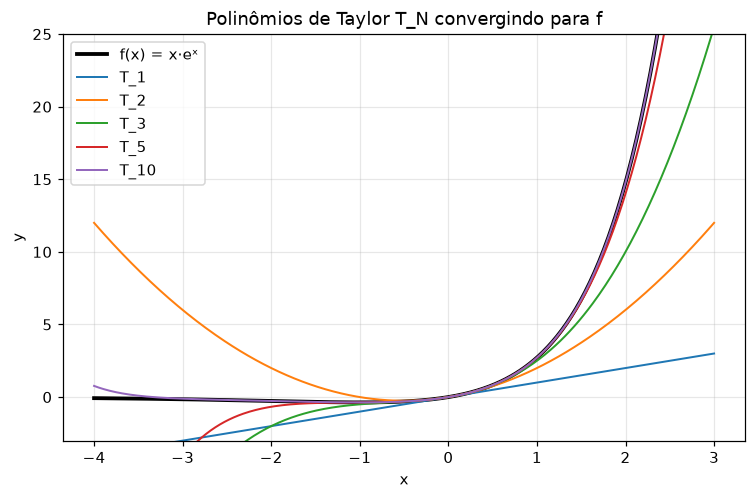

In [4]:
xs = np.linspace(-4, 3, 400)
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(xs, xs * np.exp(xs), "k", lw=2.5, label="f(x) = x·eˣ")
for N in (1, 2, 3, 5, 10):
    ax.plot(xs, taylor_x_exp_x(xs, N), lw=1.3, label=f"T_{N}")
ax.set(title="Polinômios de Taylor T_N convergindo para f", xlabel="x", ylabel="y", ylim=(-3, 25))
ax.legend()
plt.show()

**Propriedades**

- $f(0) = 0$ e $f'(0) = 1$, logo $f(x) \approx x$ perto da origem ($T_1$).
- $f'(x) = (x+1)e^x = 0 \Rightarrow x = -1$; como $f''(-1) = e^{-1} > 0$, é mínimo global: $f(-1) = -1/e \approx -0{,}368$.
- $\lim_{x \to -\infty} f(x) = 0$ (assíntota horizontal) e $\lim_{x \to +\infty} f(x) = +\infty$.
- Primitiva: $\int x e^x\,dx = (x-1)e^x + C$.

## 6. Tabela de valores mais usados

In [5]:
XS = [-5, -2, -1, -0.5, 0, 0.5, 1, 2, 5, 10]
N_SIMPLES, M_OTIM = ty.escolher_N(1, 1e-12), ty.escolher_N_reduzido()
print(f"Série simples: N = {N_SIMPLES} | otimizada: {M_OTIM} termos de e^r\n")
print(f"{'x':>5} {'exato':>16} {'simples':>16} {'erro rel.':>10} {'otimizada':>16} {'erro rel.':>10}")
for x in XS:
    s, o = ty.taylor_recorrencia(x, N_SIMPLES), ty.taylor_otimizada(x, M_OTIM)
    print(f"{x:>5} {exato(x):>16.10g} {s:>16.10g} {erro_rel(s, x):>10.1e} {o:>16.10g} {erro_rel(o, x):>10.1e}")

Série simples: N = 16 | otimizada: 13 termos de e^r

    x            exato          simples  erro rel.        otimizada  erro rel.
   -5     -0.033689735  -0.005596898914    8.3e-01     -0.033689735    4.1e-16
   -2    -0.2706705665    -0.2706705609    2.1e-08    -0.2706705665    2.1e-16
   -1    -0.3678794412    -0.3678794412    1.2e-13    -0.3678794412    0.0e+00
 -0.5    -0.3032653299    -0.3032653299    1.8e-16    -0.3032653299    0.0e+00
    0                0                0    0.0e+00                0    0.0e+00
  0.5     0.8243606354     0.8243606354    2.7e-16     0.8243606354    0.0e+00
    1      2.718281828      2.718281828    1.8e-14      2.718281828    1.6e-16
    2       14.7781122      14.77811219    4.8e-10       14.7781122    1.2e-16
    5      742.0657955      742.0145869    6.9e-05      742.0657955    1.5e-16
   10      220264.6579      209528.8697    4.9e-02      220264.6579    5.3e-16


## 7. Erros × tempo de execução

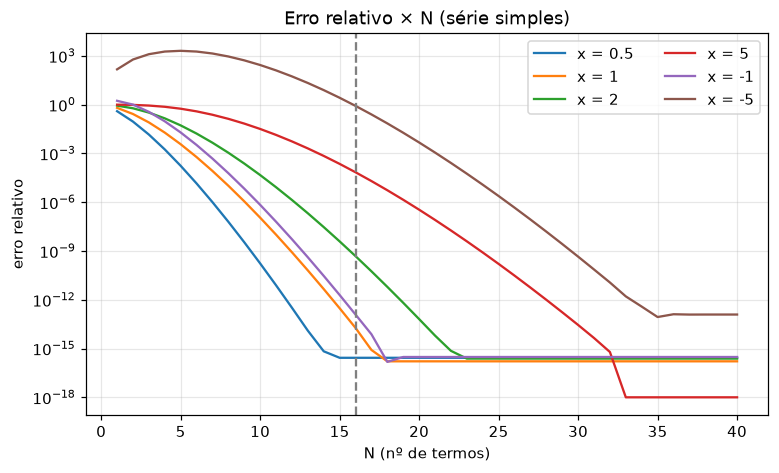

In [6]:
Ns = list(range(1, 41))
fig, ax = plt.subplots(figsize=(8, 4.5))
for x in (0.5, 1, 2, 5, -1, -5):
    ax.semilogy(Ns, [max(erro_rel(ty.taylor_recorrencia(x, N), x), 1e-18) for N in Ns], label=f"x = {x}")
ax.axvline(N_SIMPLES, color="gray", ls="--")
ax.set(title="Erro relativo × N (série simples)", xlabel="N (nº de termos)", ylabel="erro relativo")
ax.legend(ncol=2)
plt.show()

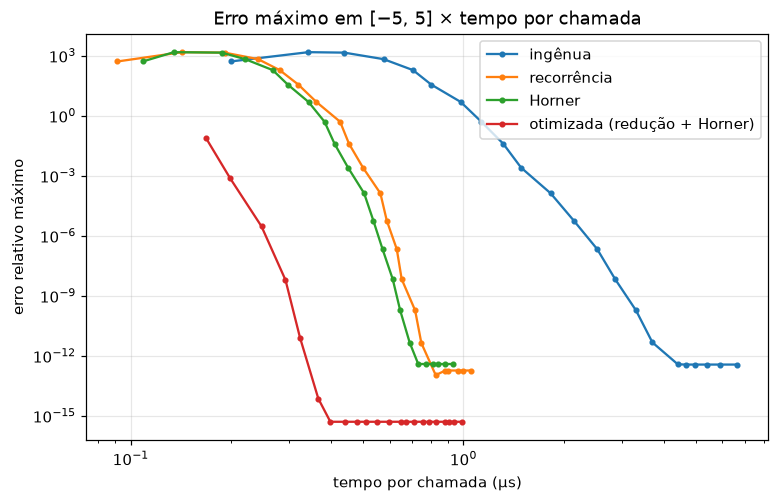

Custo para chegar a erro < 1e-10 em [-5, 5]:
  ingênua                        N = 32, 3.70 µs
  recorrência                    N = 32, 0.75 µs
  Horner                         N = 32, 0.69 µs
  otimizada (redução + Horner)   N = 10, 0.32 µs


In [7]:
A = 5
pts_x = [-A + 2 * A * (i + 0.5) / 40 for i in range(40)]
resumo = []
fig, ax = plt.subplots(figsize=(8, 4.8))
for nome, fn in ty.METODOS.items():
    curva = []
    for N in range(2, 45, 2):
        t0 = time.perf_counter()
        for _ in range(100):
            for x in pts_x:
                fn(x, N)
        dt = (time.perf_counter() - t0) / (100 * len(pts_x)) * 1e6
        curva.append((N, dt, max(erro_rel(fn(x, N), x) for x in pts_x)))
    ax.loglog([c[1] for c in curva], [max(c[2], 1e-18) for c in curva], "o-", ms=3, label=nome)
    ok = [c for c in curva if c[2] < 1e-10]
    resumo.append((nome, ok[0] if ok else None))
ax.set(title="Erro máximo em [−5, 5] × tempo por chamada",
       xlabel="tempo por chamada (µs)", ylabel="erro relativo máximo")
ax.legend()
plt.show()

print("Custo para chegar a erro < 1e-10 em [-5, 5]:")
for nome, c in resumo:
    print(f"  {nome:30s}", f"N = {c[0]:>2}, {c[1]:.2f} µs" if c else "não atingiu")

**Conclusão.** A recorrência elimina fatoriais e potências repetidas (cerca de 5× mais rápida que a versão ingênua para o mesmo erro). Horner dá um ganho pequeno. A redução de argumento reduz os termos necessários de ~32 para ~10 e mantém o erro uniforme em todo o intervalo. Os patamares dos gráficos (~$10^{-13}$ e ~$10^{-16}$) são o limite de precisão do `float64`.

Os tempos absolutos dependem da máquina.